SIMPLE LINEAR REGRESSION WITH SCRATCH

In [16]:
#section 01
#1.	Use the read_csv() function from Pandas to load the dataset into a variable.
#Extract only the last two columns ("Head Size(cm3)" and "Brain Weight(grams)")
#and store them in a new variable XY.
import pandas as pd
dataset = pd.read_csv("headbrain.csv")
print(dataset.head())
XY = dataset.iloc[:,-2:]
print(XY.head())

   Gender  Age Range  Head Size(cm^3)  Brain Weight(grams)
0       1          1             4512                 1530
1       1          1             3738                 1297
2       1          1             4261                 1335
3       1          1             3777                 1282
4       1          1             4177                 1590
   Head Size(cm^3)  Brain Weight(grams)
0             4512                 1530
1             3738                 1297
2             4261                 1335
3             3777                 1282
4             4177                 1590


In [17]:
#2.	Use the describe() function from Pandas to print the statistical summary
# (mean, standard deviation, etc.) of the data contained in XY.
summary = XY.describe()
print(summary)

       Head Size(cm^3)  Brain Weight(grams)
count       237.000000           237.000000
mean       3633.991561          1282.873418
std         365.261422           120.340446
min        2720.000000           955.000000
25%        3389.000000          1207.000000
50%        3614.000000          1280.000000
75%        3876.000000          1350.000000
max        4747.000000          1635.000000


In [18]:
#3.	Split XY into two variables: X containing "Head Size (cm3)" and
# Y containing "Brain Weight (grams)." Print the shape of both X and Y.
X = XY.iloc[:,[0]]
Y = XY.iloc[:,[1]]
print("Shape of X:",X.shape)
print("Shape of Y:",Y.shape)

Shape of X: (237, 1)
Shape of Y: (237, 1)


In [19]:
#4.	Check for missing values in X and Y
print("missing values in X: ", X.isnull().sum())
print("missing values in Y: ",Y.isnull().sum())


missing values in X:  Head Size(cm^3)    0
dtype: int64
missing values in Y:  Brain Weight(grams)    0
dtype: int64


In [20]:
#5.	Calculate the mean of X and Y and print the results.
mean_X = X.mean()
mean_Y = Y.mean()
print("mean of X:",mean_X.values[0])
print("mean of Y:",mean_Y.values[0])

mean of X: 3633.9915611814345
mean of Y: 1282.873417721519


In [21]:
#6.	If there are missing values fill up with the calculated mean value.
X = X.fillna(mean_X)
Y = Y.fillna(mean_Y)

In [22]:
#7.	Split the data into 75% train and 25% test sets.
from sklearn.model_selection import train_test_split
X_train , X_tests , Y_train, Y_tests = train_test_split(X,Y,test_size = 0.25)
print("X_train:",X_train.shape)
print("X_tests:",X_tests.shape)
print("Y_train:",Y_train.shape)
print("Y_tests:",Y_tests.shape)

X_train: (177, 1)
X_tests: (60, 1)
Y_train: (177, 1)
Y_tests: (60, 1)


3641.6553672316386
1283.0734463276835
slop: 0.2476041310560299
intercept: 381.38453351876615


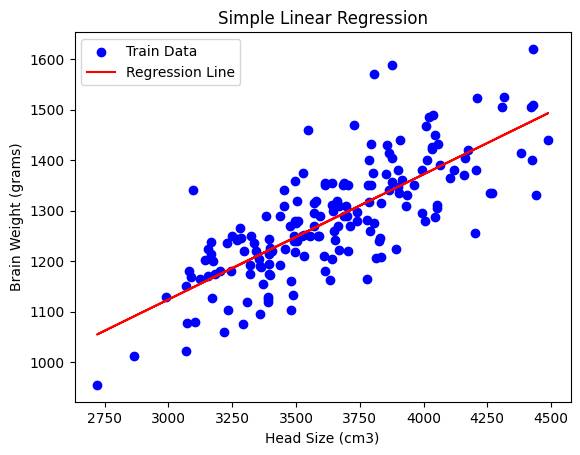

In [23]:
#8. Implement a simple linear regression model (Y = b0 + b1*X) on train set using the following steps:
#•	Write code to calculate the slope (b1) and intercept (b0).
#o	Compute the predicted values of Y based on the regression line formula: Y = b0 + b1*X.
#o	Display a scatter plot of "Head Size (cm3)" against "Brain Weight (grams)" and overlay the regression line.

import numpy as np
X_train_np = X_train.values.flatten()
Y_train_np = Y_train.values.flatten()

X_mean =np.mean(X_train_np)
Y_mean = np.mean(Y_train_np)

print(X_mean)
print(Y_mean)

#calculate slope
numerator = np.sum((X_train_np - X_mean) * (Y_train_np - Y_mean))
denominator = np.sum((X_train_np - X_mean) ** 2)
b1 = numerator / denominator
print("slop:",b1)

#calculate intercept
b0 = Y_mean - b1 * X_mean
print("intercept:",b0)

#predicted Y values
Y_pred = b0 + b1*X_train_np

import matplotlib.pyplot as plt

plt.scatter(X_train_np, Y_train_np, color="blue", label="Train Data")
plt.plot(X_train_np, Y_pred, color="red", label="Regression Line")

plt.xlabel("Head Size (cm3)")
plt.ylabel("Brain Weight (grams)")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()


In [24]:
#9.	Calculate and print the Root Mean Square Error (RMSE) for the predictions.
rmse = np.sqrt(np.mean((Y_train_np-Y_pred)**2))
print("root mean square error: ",rmse)

root mean square error:  73.03369236517447


In [25]:
#10.	Calculate the R-squared (R²) value to determine the proportion of variance explained by the model.
ss_res = np.sum((Y_train_np - Y_pred) ** 2)   # residual sum of squares
ss_tot = np.sum((Y_train_np - np.mean(Y_train_np)) ** 2)  # total sum of squares

r2 = 1 - (ss_res / ss_tot)
print("R-squared (R²):", r2)

R-squared (R²): 0.591603239230029


In [26]:
#section: 02
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score
A = XY.iloc[:,[0]]
B = XY.iloc[:,[1]]
A_train , A_test , B_train , B_test = train_test_split(A,B, test_size = 0.3, random_state=42)
model = LinearRegression()
model.fit(A_train,B_train)
B_pred = model.predict(A_test)
inbuilt_rmse = np.sqrt(mean_squared_error(B_test,B_pred))
inbuilt_r2 = r2_score(B_test,B_pred)

In [27]:
#comparison between manual and inbuilt model rmse and r-squared values
print("manual rmse: ",rmse)
print("using inbuilt model rmse: ",inbuilt_rmse)
print("manual r-squared:",r2)
print("using inbuilt model r-squared:",inbuilt_r2)

manual rmse:  73.03369236517447
using inbuilt model rmse:  67.95527201634788
manual r-squared: 0.591603239230029
using inbuilt model r-squared: 0.6993002108399291
